<a href="https://colab.research.google.com/github/Taimaraliz/TechCorp-Brasil/blob/main/Trabalho_em_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 **TRABALHO em R - LINGUAGENS DE PROGRAMAÇÃO PARA DADOS E ANALYTICS**

**Alunos
**Fábio
** Taimara
** Laiane
** Tatiane Silva Santos  RA:10747108
**Professor:** Me. Jonnathan Martins  
**Turma:** G - 2025  
**MBA em Engenharia de Dados - Mackenzie**

In [2]:
#1. Importe o seu dataset para o R.

dados_agricola <- "/content/evolucao_temporal.csv"

In [5]:
#1.1 Carregando pacotes necessários

install.packages(c("sidrar", "dplyr", "tidyr", "ggplot2", "readr", "janitor"))
library(readr)
library(sidrar)
library(janitor)
library(dplyr)
library(tidyr)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




**2. Contextualize o problema de negócio relacionado ao seu dataset**

O agronegócio, responsável por 25% do PIB brasileiro, sofreu impactos na produção de soja, milho e arroz durante a pandemia. Avaliar a evolução por produto e estado é essencial para entender os efeitos e a retomada a partir de 2022. Com a pandemia de COVID-19 (2020–2021), houve impactos na produção agrícola devido a restrições logísticas, mão de obra e exportação. O problema de negócio aqui é entender se a produção dessas lavouras cresceu ou caiu nesse período crítico e no início da recuperação econômica (de 2020 a 2022).

**3. Contextualize a solução que seu pipeline deverá resolver (Questão aberta)**

*O pipeline em R:*

Ler e organizar os dados da Tabela 1612 do SIDRA/IBGE.

Selecionar produtos específicos (ex.: soja, milho, arroz).

Agrupar por ano (2020, 2021, 2022).

Calcular a produção total em cada ano.

Visualizar a evolução (tabelas e gráficos de linha).

In [6]:

dim(dados_agricola)
print(paste("O dataset tem", nrow(dados_agricola), "linhas e",
            ncol(dados_agricola), "colunas"))

NULL

[1] "O dataset tem  linhas e  colunas"


In [7]:
dados_agricola <- get_sidra(x = 1612,
                            period = c("2020", "2021", "2022"),
                            geo = "State")

Considering all categories once 'classific' was set to 'all' (default)



In [8]:
# =============================================================================
# QUESTÃO 04:Verifique as primeiras 6 linhas do dataset.
# =============================================================================

head(dados_agricola, 6)

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2,3,Unidade da Federação,1006,Hectares,721910,11,Rondônia,2020,2020,109,Área plantada,0,Total
3,3,Unidade da Federação,1006,Hectares,938,11,Rondônia,2020,2020,109,Área plantada,2688,Abacaxi*
4,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,40471,Alfafa fenada
5,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2689,Algodão herbáceo (em caroço)
6,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2690,Alho
7,3,Unidade da Federação,1006,Hectares,128,11,Rondônia,2020,2020,109,Área plantada,2691,Amendoim (em casca)


In [12]:
# =============================================================================
# QUESTÃO 05: Verifique as últimas 10 linhas do dataset.
# =============================================================================

tail(dados_agricola)

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
13766,3,Unidade da Federação,40,Mil Reais,NA,53,Distrito Federal,2022,2022,215,Valor da produção,2712,Rami (fibra)
13767,3,Unidade da Federação,40,Mil Reais,915926,53,Distrito Federal,2022,2022,215,Valor da produção,2713,Soja (em grão)
13768,3,Unidade da Federação,40,Mil Reais,22800,53,Distrito Federal,2022,2022,215,Valor da produção,2714,Sorgo (em grão)
13769,3,Unidade da Federação,40,Mil Reais,100800,53,Distrito Federal,2022,2022,215,Valor da produção,2715,Tomate
13770,3,Unidade da Federação,40,Mil Reais,32625,53,Distrito Federal,2022,2022,215,Valor da produção,2716,Trigo (em grão)
13771,3,Unidade da Federação,40,Mil Reais,NA,53,Distrito Federal,2022,2022,215,Valor da produção,109180,Triticale (em grão)


In [13]:
# =============================================================================
# QUESTÃO 06: Mostre a quantidade de linhas e colunas do dataset
# =============================================================================

dim(dados_agricola)


[1] 13770    13

In [14]:

estados <- unique(dados_agricola$`Unidade da Federação`)
estados
# Quantos estados temos?
length(estados)

[1] "Rondônia"            "Acre"                "Amazonas"           
 [4] "Roraima"             "Pará"                "Amapá"              
 [7] "Tocantins"           "Maranhão"            "Piauí"              
[10] "Ceará"               "Rio Grande do Norte" "Paraíba"            
[13] "Pernambuco"          "Alagoas"             "Sergipe"            
[16] "Bahia"               "Minas Gerais"        "Espírito Santo"     
[19] "Rio de Janeiro"      "São Paulo"           "Paraná"             
[22] "Santa Catarina"      "Rio Grande do Sul"   "Mato Grosso do Sul" 
[25] "Mato Grosso"         "Goiás"               "Distrito Federal"

[1] 27

In [15]:
# =============================================================================
# QUESTÃO 07: Exiba apenas os nomes das colunas do dataset.
# =============================================================================
colnames(dados_agricola)


[1] "Nível Territorial (Código)"               
 [2] "Nível Territorial"                        
 [3] "Unidade de Medida (Código)"               
 [4] "Unidade de Medida"                        
 [5] "Valor"                                    
 [6] "Unidade da Federação (Código)"            
 [7] "Unidade da Federação"                     
 [8] "Ano (Código)"                             
 [9] "Ano"                                      
[10] "Variável (Código)"                        
[11] "Variável"                                 
[12] "Produto das lavouras temporárias (Código)"
[13] "Produto das lavouras temporárias"

**8. Descreva em poucas palavras as principais variáveis**

Ano: período de referência (2020, 2021, 2022).

Produto (lavoura): tipo de cultivo (soja, milho, arroz etc.).

Valor: quantidade produzida ou valor de produção.

Unidade: especifica se o valor está em hectares, toneladas ou reais.

Estado: unidade geográfica da observação.

In [16]:
install.packages("dplyr")
library(tidyr)
library(ggplot2)
library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [17]:
library(dplyr)

In [18]:
# =============================================================================
# QUESTÃO 9: Verificar e ajustar os tipos das colunas
# =============================================================================
str(dados_agricola)


dados_agricola <- dados_agricola %>%
  mutate(
    Ano = as.integer(`Ano`),
    Estado = as.factor(`Unidade da Federação`),
    Produto = as.factor(`Produto das lavouras temporárias`),
    Valor = as.numeric(`Valor`)
  )

'data.frame':	13770 obs. of  13 variables:
 $ Nível Territorial (Código)               : chr  "3" "3" "3" "3" ...
 $ Nível Territorial                        : chr  "Unidade da Federação" "Unidade da Federação" "Unidade da Federação" "Unidade da Federação" ...
 $ Unidade de Medida (Código)               : chr  "1006" "1006" "1006" "1006" ...
 $ Unidade de Medida                        : chr  "Hectares" "Hectares" "Hectares" "Hectares" ...
 $ Valor                                    : num  721910 938 NA NA NA ...
 $ Unidade da Federação (Código)            : chr  "11" "11" "11" "11" ...
 $ Unidade da Federação                     : chr  "Rondônia" "Rondônia" "Rondônia" "Rondônia" ...
 $ Ano (Código)                             : chr  "2020" "2020" "2020" "2020" ...
 $ Ano                                      : chr  "2020" "2020" "2020" "2020" ...
 $ Variável (Código)                        : chr  "109" "109" "109" "109" ...
 $ Variável                                 : chr  "Área planta

In [22]:
# =============================================================================
# QUESTÃO 10. Selecionar apenas duas colunas
# =============================================================================

dados_produto_estado <- dados_agricola %>%
  select(`Produto das lavouras temporárias`, `Unidade da Federação`)

In [23]:
# =============================================================================
# QUESTÃO 11. Filtrar linhas com variável numérica maior que um valor
# =============================================================================
#produção maior que 1 milhão de toneladas:

dados_agricola %>%
  filter(Valor > 1000000)

Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias,Estado,Produto
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>
3,Unidade da Federação,1017,Toneladas,1036905,11,Rondônia,2020,2020,214,Quantidade produzida,2711,Milho (em grão),Rondônia,Milho (em grão)
3,Unidade da Federação,1017,Toneladas,1348724,11,Rondônia,2020,2020,214,Quantidade produzida,2713,Soja (em grão),Rondônia,Soja (em grão)
3,Unidade da Federação,40,Mil Reais,3265303,11,Rondônia,2020,2020,215,Valor da produção,0,Total,Rondônia,Total
3,Unidade da Federação,40,Mil Reais,1676618,11,Rondônia,2020,2020,215,Valor da produção,2713,Soja (em grão),Rondônia,Soja (em grão)
3,Unidade da Federação,1017,Toneladas,1232783,11,Rondônia,2021,2021,214,Quantidade produzida,2711,Milho (em grão),Rondônia,Milho (em grão)
3,Unidade da Federação,1017,Toneladas,1352087,11,Rondônia,2021,2021,214,Quantidade produzida,2713,Soja (em grão),Rondônia,Soja (em grão)
3,Unidade da Federação,40,Mil Reais,5601548,11,Rondônia,2021,2021,215,Valor da produção,0,Total,Rondônia,Total
3,Unidade da Federação,40,Mil Reais,1471400,11,Rondônia,2021,2021,215,Valor da produção,2711,Milho (em grão),Rondônia,Milho (em grão)
3,Unidade da Federação,40,Mil Reais,3360818,11,Rondônia,2021,2021,215,Valor da produção,2713,Soja (em grão),Rondônia,Soja (em grão)


In [24]:
# =============================================================================
# QUESTÃO 12. Ordenar dataset de forma crescente com base em uma coluna
# =============================================================================

#Exemplo: ordenar pela produção (Valor):

dados_agricola %>%
  arrange(Valor)

Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias,Estado,Produto
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>
3,Unidade da Federação,1006,Hectares,1,17,Tocantins,2020,2020,109,Área plantada,2694,Batata-doce,Tocantins,Batata-doce
3,Unidade da Federação,1006,Hectares,1,17,Tocantins,2020,2020,216,Área colhida,2694,Batata-doce,Tocantins,Batata-doce
3,Unidade da Federação,1017,Toneladas,1,17,Tocantins,2020,2020,214,Quantidade produzida,2694,Batata-doce,Tocantins,Batata-doce
3,Unidade da Federação,1017,Toneladas,1,17,Tocantins,2020,2020,214,Quantidade produzida,2701,Fava (em grão),Tocantins,Fava (em grão)
3,Unidade da Federação,40,Mil Reais,1,17,Tocantins,2020,2020,215,Valor da produção,2694,Batata-doce,Tocantins,Batata-doce
3,Unidade da Federação,1006,Hectares,1,27,Alagoas,2022,2022,109,Área plantada,2695,Batata-inglesa,Alagoas,Batata-inglesa
3,Unidade da Federação,1006,Hectares,1,27,Alagoas,2022,2022,216,Área colhida,2695,Batata-inglesa,Alagoas,Batata-inglesa
3,Unidade da Federação,1006,Hectares,2,21,Maranhão,2021,2021,109,Área plantada,2694,Batata-doce,Maranhão,Batata-doce
3,Unidade da Federação,1006,Hectares,2,21,Maranhão,2021,2021,216,Área colhida,2694,Batata-doce,Maranhão,Batata-doce


In [25]:
#13. Criar uma nova coluna a partir de duas existentes

dados_com_categoria <- dados_agricola %>%
  filter(!is.na(Valor)) %>%  # remove linhas sem valor
  mutate(categoria_valor = case_when(
    Valor < 1000 ~ "Baixo",
    Valor >= 1000 & Valor < 10000 ~ "Médio",
    Valor >= 10000 ~ "Alto"
  ))

# Visualizar as primeiras linhas
head(dados_com_categoria)

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias,Estado,Produto,categoria_valor
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>,<chr>
1,3,Unidade da Federação,1006,Hectares,721910,11,Rondônia,2020,2020,109,Área plantada,0,Total,Rondônia,Total,Alto
2,3,Unidade da Federação,1006,Hectares,938,11,Rondônia,2020,2020,109,Área plantada,2688,Abacaxi*,Rondônia,Abacaxi*,Baixo
3,3,Unidade da Federação,1006,Hectares,128,11,Rondônia,2020,2020,109,Área plantada,2691,Amendoim (em casca),Rondônia,Amendoim (em casca),Baixo
4,3,Unidade da Federação,1006,Hectares,40859,11,Rondônia,2020,2020,109,Área plantada,2692,Arroz (em casca),Rondônia,Arroz (em casca),Alto
5,3,Unidade da Federação,1006,Hectares,754,11,Rondônia,2020,2020,109,Área plantada,2696,Cana-de-açúcar,Rondônia,Cana-de-açúcar,Baixo
6,3,Unidade da Federação,1006,Hectares,16547,11,Rondônia,2020,2020,109,Área plantada,2702,Feijão (em grão),Rondônia,Feijão (em grão),Alto


In [26]:
#14. Remova uma coluna do dataset.
# Remover a coluna "Nível Territorial"
dados_agricola <- dados_agricola %>%
  select(-`Nível Territorial`)

# Verificar resultado
head(dados_agricola)

,Nível Territorial (Código),Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias,Estado,Produto
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>
2,3,1006,Hectares,721910,11,Rondônia,2020,2020,109,Área plantada,0,Total,Rondônia,Total
3,3,1006,Hectares,938,11,Rondônia,2020,2020,109,Área plantada,2688,Abacaxi*,Rondônia,Abacaxi*
4,3,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,40471,Alfafa fenada,Rondônia,Alfafa fenada
5,3,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2689,Algodão herbáceo (em caroço),Rondônia,Algodão herbáceo (em caroço)
6,3,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2690,Alho,Rondônia,Alho
7,3,1006,Hectares,128,11,Rondônia,2020,2020,109,Área plantada,2691,Amendoim (em casca),Rondônia,Amendoim (em casca)


In [27]:
#15.Use a função select() para escolher 3 colunas do dataset.
# Selecionando 3 colunas específicas
dados_selecionados <- dados_agricola %>%
  select(`Ano`, `Unidade da Federação`, `Valor`)

# Visualizar o resultado
head(dados_selecionados)

,Ano,Unidade da Federação,Valor
,<int>,<chr>,<dbl>
2,2020,Rondônia,721910
3,2020,Rondônia,938
4,2020,Rondônia,NA
5,2020,Rondônia,NA
6,2020,Rondônia,NA
7,2020,Rondônia,128


In [28]:
#16.Use a função filter() para selecionar linhas que atendam a uma condição.
# Filtrando linhas onde Valor > 1000

dados_agricola <- get_sidra(x = 1612,
                            period = c("2020", "2021", "2022"),
                            geo = "State")

# Conferir os dados
head(dados_agricola)
str(dados_agricola)

Considering all categories once 'classific' was set to 'all' (default)



,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2,3,Unidade da Federação,1006,Hectares,721910,11,Rondônia,2020,2020,109,Área plantada,0,Total
3,3,Unidade da Federação,1006,Hectares,938,11,Rondônia,2020,2020,109,Área plantada,2688,Abacaxi*
4,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,40471,Alfafa fenada
5,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2689,Algodão herbáceo (em caroço)
6,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2690,Alho
7,3,Unidade da Federação,1006,Hectares,128,11,Rondônia,2020,2020,109,Área plantada,2691,Amendoim (em casca)


'data.frame':	13770 obs. of  13 variables:
 $ Nível Territorial (Código)               : chr  "3" "3" "3" "3" ...
 $ Nível Territorial                        : chr  "Unidade da Federação" "Unidade da Federação" "Unidade da Federação" "Unidade da Federação" ...
 $ Unidade de Medida (Código)               : chr  "1006" "1006" "1006" "1006" ...
 $ Unidade de Medida                        : chr  "Hectares" "Hectares" "Hectares" "Hectares" ...
 $ Valor                                    : num  721910 938 NA NA NA ...
 $ Unidade da Federação (Código)            : chr  "11" "11" "11" "11" ...
 $ Unidade da Federação                     : chr  "Rondônia" "Rondônia" "Rondônia" "Rondônia" ...
 $ Ano (Código)                             : chr  "2020" "2020" "2020" "2020" ...
 $ Ano                                      : chr  "2020" "2020" "2020" "2020" ...
 $ Variável (Código)                        : chr  "109" "109" "109" "109" ...
 $ Variável                                 : chr  "Área planta

In [30]:
#17. Selecione todas as colunas cujo nome começa com uma letra específica usando select(starts_with()).

# Selecionar colunas que começam com "A"
colunas_a <- dados_agricola %>%
  select(starts_with("A"))

# Visualizar as primeiras linhas
head(colunas_a)


,Ano (Código),Ano
,<chr>,<chr>
2,2020,2020
3,2020,2020
4,2020,2020
5,2020,2020
6,2020,2020
7,2020,2020


In [31]:
#18. Renomeie duas colunas do dataset usando rename().

# Renomeando duas colunas
dados_renomeados <- dados_agricola %>%
  rename(
    Estado = `Unidade da Federação`,        # renomeia a coluna para "Estado"
    Produto = `Produto das lavouras temporárias`  # renomeia para "Produto"
  )

# Verificar as primeiras linhas e os nomes das colunas
head(dados_renomeados)
names(dados_renomeados)


,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Estado,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2,3,Unidade da Federação,1006,Hectares,721910,11,Rondônia,2020,2020,109,Área plantada,0,Total
3,3,Unidade da Federação,1006,Hectares,938,11,Rondônia,2020,2020,109,Área plantada,2688,Abacaxi*
4,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,40471,Alfafa fenada
5,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2689,Algodão herbáceo (em caroço)
6,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2690,Alho
7,3,Unidade da Federação,1006,Hectares,128,11,Rondônia,2020,2020,109,Área plantada,2691,Amendoim (em casca)


[1] "Nível Territorial (Código)"               
 [2] "Nível Territorial"                        
 [3] "Unidade de Medida (Código)"               
 [4] "Unidade de Medida"                        
 [5] "Valor"                                    
 [6] "Unidade da Federação (Código)"            
 [7] "Estado"                                   
 [8] "Ano (Código)"                             
 [9] "Ano"                                      
[10] "Variável (Código)"                        
[11] "Variável"                                 
[12] "Produto das lavouras temporárias (Código)"
[13] "Produto"

In [32]:
#20.Crie uma nova coluna com mutate().


dados_agricola <- dados_agricola %>%
  mutate(Valor_mil = as.numeric(Valor) / 1000)

# Visualizar as primeiras linhas
head(dados_agricola)

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias,Valor_mil
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
2,3,Unidade da Federação,1006,Hectares,721910,11,Rondônia,2020,2020,109,Área plantada,0,Total,721.910
3,3,Unidade da Federação,1006,Hectares,938,11,Rondônia,2020,2020,109,Área plantada,2688,Abacaxi*,0.938
4,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,40471,Alfafa fenada,NA
5,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2689,Algodão herbáceo (em caroço),NA
6,3,Unidade da Federação,1006,Hectares,NA,11,Rondônia,2020,2020,109,Área plantada,2690,Alho,NA
7,3,Unidade da Federação,1006,Hectares,128,11,Rondônia,2020,2020,109,Área plantada,2691,Amendoim (em casca),0.128


In [33]:
library(dplyr)
library(ggplot2)
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




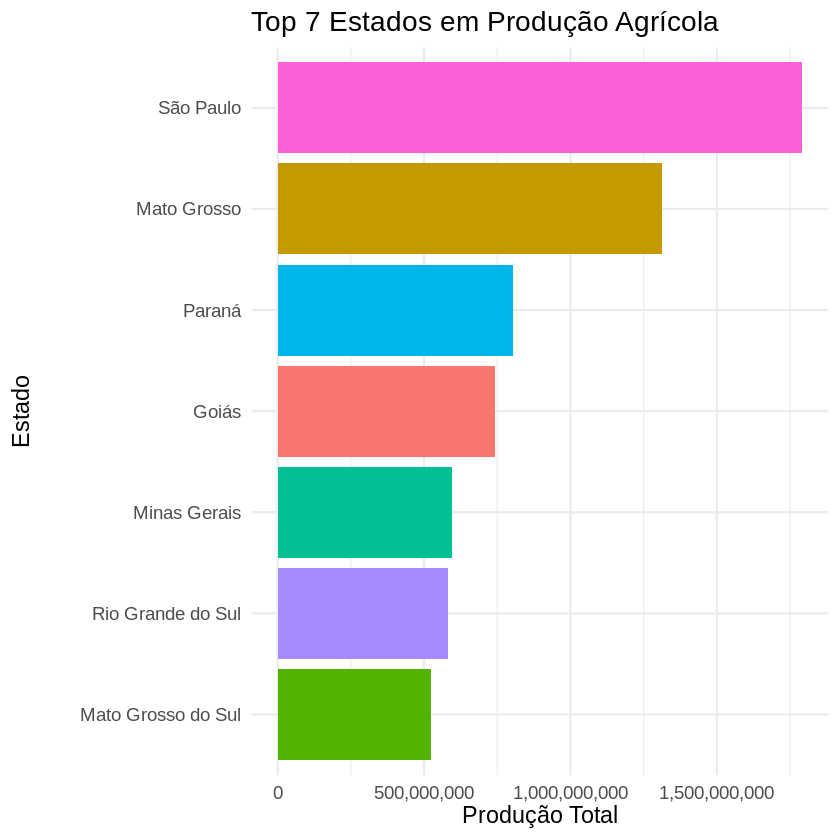

In [34]:
#20.1 Criando grafico das colunas
# Somar produção total por estado e pegar as 7 maiores
prod_top7 <- dados_agricola %>%
  group_by(`Unidade da Federação`) %>%  # coluna correta para estados
  summarise(total_prod = sum(as.numeric(Valor), na.rm = TRUE)) %>%
  arrange(desc(total_prod)) %>%
  slice_head(n = 7)

# Gráfico de barras horizontal
ggplot(prod_top7, aes(x = reorder(`Unidade da Federação`, total_prod), y = total_prod, fill = `Unidade da Federação`)) +
  geom_col() +
  coord_flip() +
  theme_minimal(base_size = 14) +
  labs(title = "Top 7 Estados em Produção Agrícola",
       x = "Estado",
       y = "Produção Total") +
  scale_y_continuous(labels = comma) +
  theme(legend.position = "none")



In [36]:
#21. Resuma os dados de uma coluna numérica usando summarise().

resumo_valor <- dados_agricola %>%
  summarise(
    media = mean(as.numeric(Valor), na.rm = TRUE),
    mediana = median(as.numeric(Valor), na.rm = TRUE),
    minimo = min(as.numeric(Valor), na.rm = TRUE),
    maximo = max(as.numeric(Valor), na.rm = TRUE),
    total = sum(as.numeric(Valor), na.rm = TRUE),
    registros = n()
  )

resumo_valor



media,mediana,minimo,maximo,total,registros
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1120480,11400,1,431525560,7595736403,13770


In [37]:
#22. Agrupe os dados por uma variável categórica com group_by().

resumo_por_estado <- dados_agricola %>%
  group_by(`Unidade da Federação`) %>%
  summarise(
    total_valor = sum(as.numeric(Valor), na.rm = TRUE),
    media_valor = mean(as.numeric(Valor), na.rm = TRUE),
    registros = n(),
    .groups = 'drop'
  )

# Visualizar o resultado
head(resumo_por_estado)


Unidade da Federação,total_valor,media_valor,registros
<chr>,<dbl>,<dbl>,<int>
Acre,5942666,34153.25,510
Alagoas,71995129,272708.82,510
Amapá,1765844,13688.71,510
Amazonas,12869491,64670.81,510
Bahia,266823902,863507.77,510
Ceará,34886072,122407.27,510


In [38]:
#23.Combine group_by() e summarise() para calcular a média de uma variável por grupo.

produtos_resumo <- dados_agricola %>%
  group_by(`Produto das lavouras temporárias`) %>%
  summarise(
    producao_total = sum(as.numeric(Valor), na.rm = TRUE),
    producao_media = mean(as.numeric(Valor), na.rm = TRUE),
    num_estados = n_distinct(`Unidade da Federação`),
    .groups = "drop"
  ) %>%
  arrange(desc(producao_total))


estados_resumo <- dados_agricola %>%
  group_by(`Unidade da Federação`) %>%
  summarise(
    producao_total = sum(as.numeric(Valor), na.rm = TRUE),
    producao_media = mean(as.numeric(Valor), na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(producao_total)) %>%
  slice_head(n = 10)


evolucao_anual <- dados_agricola %>%
  group_by(Ano) %>%
  summarise(
    producao_total = sum(as.numeric(Valor), na.rm = TRUE),
    producao_media = mean(as.numeric(Valor), na.rm = TRUE),
    .groups = "drop"
  )

produtos_resumo
estados_resumo
evolucao_anual



Produto das lavouras temporárias,producao_total,producao_media,num_estados
<chr>,<dbl>,<dbl>,<int>
Cana-de-açúcar,2492060132,6153234.894,27
Total,2248531772,9253217.169,27
Soja (em grão),1470388001,4324670.591,27
Milho (em grão),746401200,1842965.926,27
Algodão herbáceo (em caroço),106783623,464276.622,27
Mandioca,101992765,251833.988,27
Arroz (em casca),90169564,231204.010,27
Trigo (em grão),74873001,512828.774,27
Feijão (em grão),60315709,148927.677,27


Unidade da Federação,producao_total,producao_media
<chr>,<dbl>,<dbl>
São Paulo,1791277586,4789512.3
Mato Grosso,1313740151,5276064.9
Paraná,804928276,2096167.4
Goiás,742611089,2812920.8
Minas Gerais,594099910,1752507.1
Rio Grande do Sul,582714243,1460436.7
Mato Grosso do Sul,523176202,2059748.8
Bahia,266823902,863507.8
Santa Catarina,126801123,410359.6


Ano,producao_total,producao_media
<chr>,<dbl>,<dbl>
2020,2152134439,947659.4
2021,2636203772,1165430.5
2022,2807398192,1249954.7


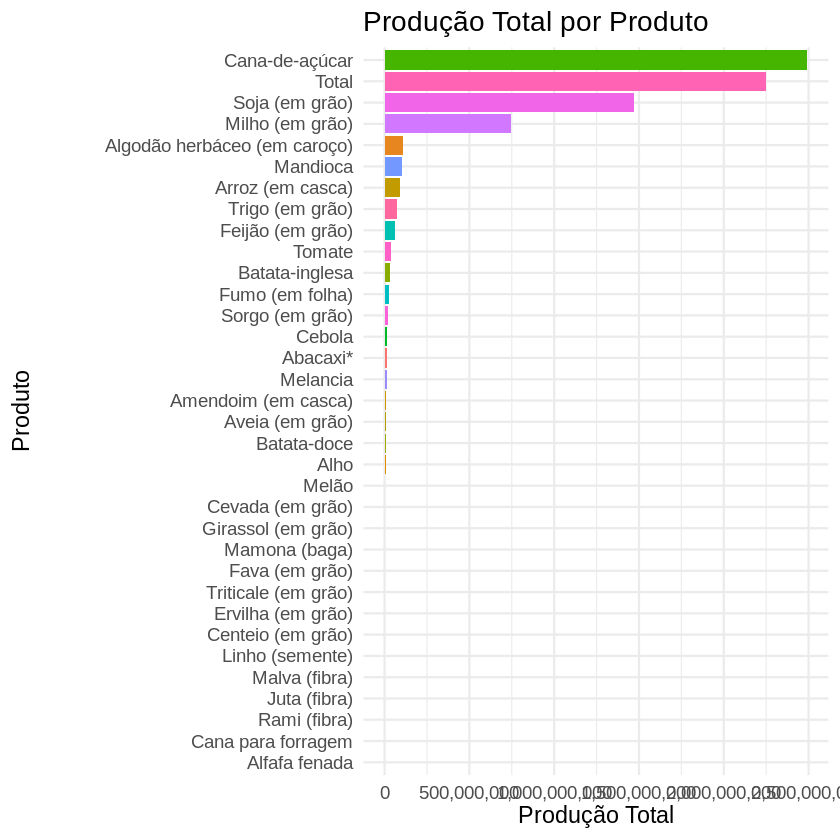

In [39]:
library(ggplot2)
library(scales)

#Gráfico: Produção total por Produto
ggplot(produtos_resumo, aes(x = reorder(`Produto das lavouras temporárias`, producao_total),
                            y = producao_total, fill = `Produto das lavouras temporárias`)) +
  geom_col() +
  coord_flip() +
  theme_minimal(base_size = 14) +
  labs(title = "Produção Total por Produto",
       x = "Produto",
       y = "Produção Total") +
  scale_y_continuous(labels = comma) +
  theme(legend.position = "none")


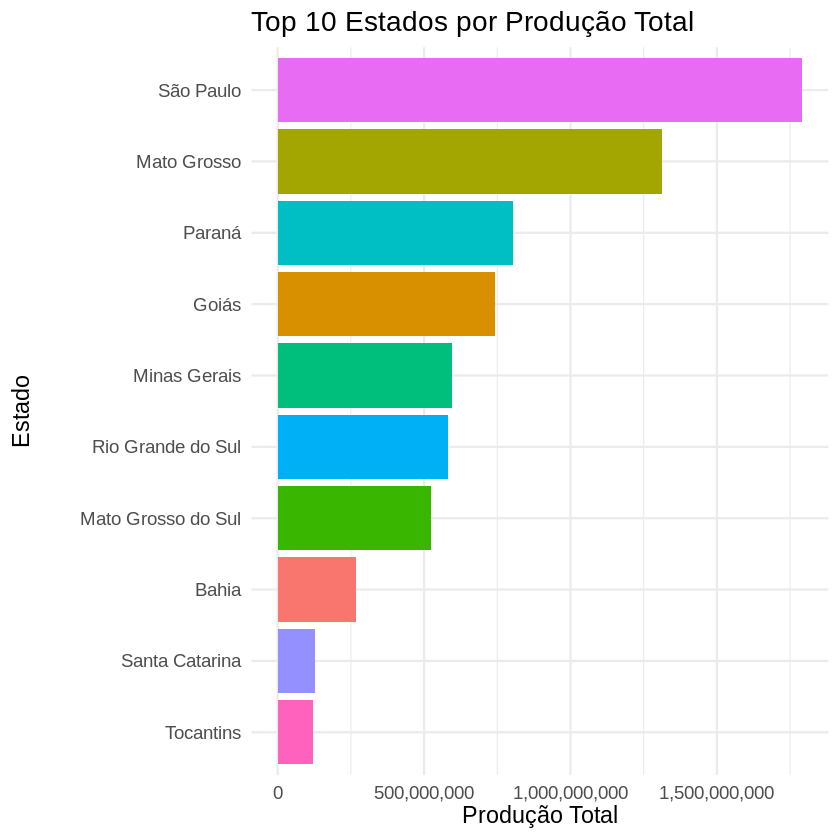

In [40]:

# Gráfico: Top 10 Estados por Produção Total

ggplot(estados_resumo, aes(x = reorder(`Unidade da Federação`, producao_total),
                           y = producao_total, fill = `Unidade da Federação`)) +
  geom_col() +
  coord_flip() +
  theme_minimal(base_size = 14) +
  labs(title = "Top 10 Estados por Produção Total",
       x = "Estado",
       y = "Produção Total") +
  scale_y_continuous(labels = comma) +
  theme(legend.position = "none")



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


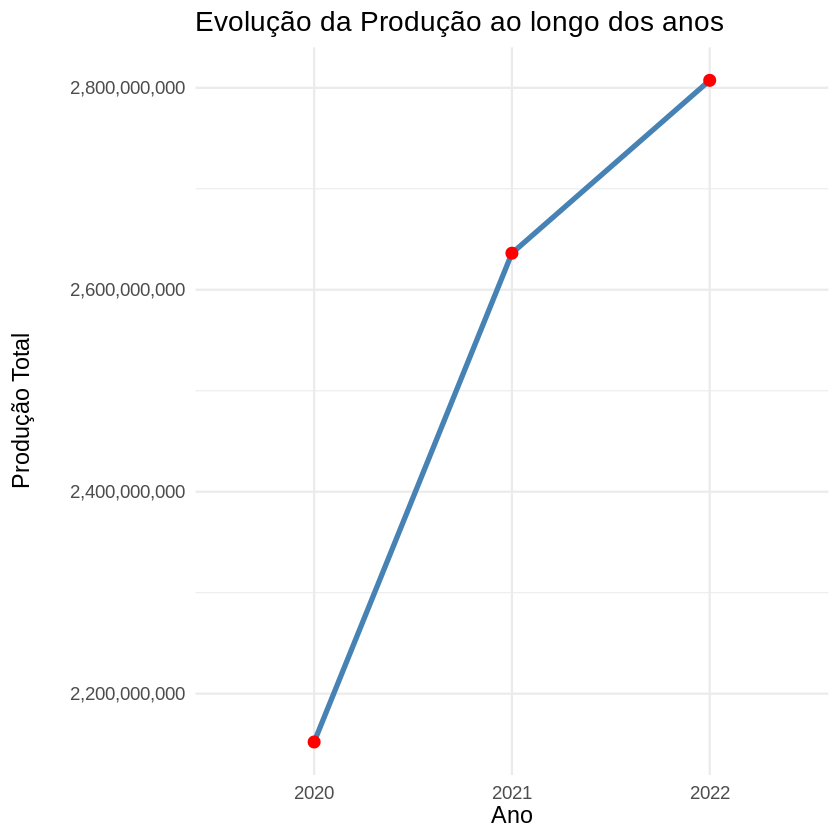

In [41]:
#Gráfico: Evolução da Produção ao longo dos anos

ggplot(evolucao_anual, aes(x = Ano, y = producao_total)) +
  geom_line(group = 1, color = "steelblue", size = 1.5) +
  geom_point(color = "red", size = 3) +
  theme_minimal(base_size = 14) +
  labs(title = "Evolução da Produção ao longo dos anos",
       x = "Ano",
       y = "Produção Total") +
  scale_y_continuous(labels = comma)


In [45]:
#24.Use pivot_longer() para transformar colunas em linhas.
library(dplyr)
library(tidyr)

dados_exemplo <- data.frame(
  Estado = c("SP", "MG", "RS"),
  Arroz = c(1000, 800, 600),
  Milho = c(2000, 1800, 1500),
  Soja = c(3000, 2500, 2200)
)

dados_long <- dados_exemplo %>%
  pivot_longer(
    cols = -Estado,
    names_to = "Produto",
    values_to = "Producao"
  )

print(dados_long)

# A tibble: 9 × 3
  Estado Produto Producao
  <chr>  <chr>      <dbl>
1 SP     Arroz       1000
2 SP     Milho       2000
3 SP     Soja        3000
4 MG     Arroz        800
5 MG     Milho       1800
6 MG     Soja        2500
7 RS     Arroz        600
8 RS     Milho       1500
9 RS     Soja        2200


In [46]:
#25.Utilize um pipeline para: selecionar colunas, filtrar linhas e ordenar os dados.

dados_filtrados <- dados_agricola %>%
  select(Estado = `Unidade da Federação`, Produto = `Produto das lavouras temporárias`, Valor = `Valor`) %>%
  filter(as.numeric(Valor) > 1000) %>%
  arrange(desc(as.numeric(Valor)))

head(dados_filtrados, 10)


,Estado,Produto,Valor
,<chr>,<chr>,<dbl>
1,São Paulo,Cana-de-açúcar,431525560
2,São Paulo,Cana-de-açúcar,420724619
3,São Paulo,Cana-de-açúcar,405000643
4,Mato Grosso,Total,174424414
5,Mato Grosso,Total,151356051
6,Mato Grosso,Soja (em grão),105106390
7,Mato Grosso,Soja (em grão),88100858
8,Rio Grande do Sul,Total,86786154
9,São Paulo,Total,80693111


In [47]:
# Mostrar todos os produtos disponíveis no dataset
unique(dados_agricola$`Produto das lavouras temporárias`)

[1] "Total"                        "Abacaxi*"                    
 [3] "Alfafa fenada"                "Algodão herbáceo (em caroço)"
 [5] "Alho"                         "Amendoim (em casca)"         
 [7] "Arroz (em casca)"             "Aveia (em grão)"             
 [9] "Batata-doce"                  "Batata-inglesa"              
[11] "Cana-de-açúcar"               "Cana para forragem"          
[13] "Cebola"                       "Centeio (em grão)"           
[15] "Cevada (em grão)"             "Ervilha (em grão)"           
[17] "Fava (em grão)"               "Feijão (em grão)"            
[19] "Fumo (em folha)"              "Girassol (em grão)"          
[21] "Juta (fibra)"                 "Linho (semente)"             
[23] "Malva (fibra)"                "Mamona (baga)"               
[25] "Mandioca"                     "Melancia"                    
[27] "Melão"                        "Milho (em grão)"             
[29] "Rami (fibra)"                 "Soja (em grão)"              
[31] "Sorgo (em grão)"              "Tomate"                      
[33] "Trigo (em grão)"              "Triticale (em grão)"

In [48]:
#26.Use pivot_wider() para transformar linhas em colunas. Corrigindo dados NA
library(dplyr)
library(tidyr)

amostra_dados <- dados_agricola %>%
  filter(`Unidade da Federação` %in% c("São Paulo", "Minas Gerais", "Paraná"),
         `Produto das lavouras temporárias` %in% c("Milho (em grão)", "Soja (em grão)", "Arroz (em casca)")) %>%
  select(`Unidade da Federação`, `Produto das lavouras temporárias`, Valor) %>%
  rename(
    Estado = `Unidade da Federação`,
    Produto = `Produto das lavouras temporárias`
  ) %>%
  mutate(Valor = as.numeric(Valor)) %>%
  head(10)

amostra_dados





,Estado,Produto,Valor
,<chr>,<chr>,<dbl>
1,Minas Gerais,Arroz (em casca),2785
2,Minas Gerais,Milho (em grão),1139726
3,Minas Gerais,Soja (em grão),1695702
4,Minas Gerais,Arroz (em casca),2544
5,Minas Gerais,Milho (em grão),1119388
6,Minas Gerais,Soja (em grão),1695672
7,Minas Gerais,Arroz (em casca),7936
8,Minas Gerais,Milho (em grão),7689309
9,Minas Gerais,Soja (em grão),6218740


In [49]:
#27. Aplique drop_na() para remover valores ausentes.

dados_sem_na <- dados_agricola %>%
  drop_na()

dados_sem_na_valor <- dados_agricola %>%
  drop_na(Valor)

dim(dados_sem_na)
dim(dados_sem_na_valor)
head(dados_sem_na_valor)


[1] 6779   14

[1] 6779   14

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias,Valor_mil
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,3,Unidade da Federação,1006,Hectares,721910,11,Rondônia,2020,2020,109,Área plantada,0,Total,721.910
2,3,Unidade da Federação,1006,Hectares,938,11,Rondônia,2020,2020,109,Área plantada,2688,Abacaxi*,0.938
3,3,Unidade da Federação,1006,Hectares,128,11,Rondônia,2020,2020,109,Área plantada,2691,Amendoim (em casca),0.128
4,3,Unidade da Federação,1006,Hectares,40859,11,Rondônia,2020,2020,109,Área plantada,2692,Arroz (em casca),40.859
5,3,Unidade da Federação,1006,Hectares,754,11,Rondônia,2020,2020,109,Área plantada,2696,Cana-de-açúcar,0.754
6,3,Unidade da Federação,1006,Hectares,16547,11,Rondônia,2020,2020,109,Área plantada,2702,Feijão (em grão),16.547


In [50]:
#28. Substitua valores ausentes por 0 em uma coluna numérica.
library(dplyr)
library(tidyr)

# Substituir NA por 0 na coluna Valor
dados_valor_zero <- dados_agricola %>%
  mutate(Valor = replace_na(Valor, 0))

# Conferir resultado
sum(is.na(dados_valor_zero$Valor))
head(dados_valor_zero)


[1] 0

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Ano (Código),Ano,Variável (Código),Variável,Produto das lavouras temporárias (Código),Produto das lavouras temporárias,Valor_mil
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
2,3,Unidade da Federação,1006,Hectares,721910,11,Rondônia,2020,2020,109,Área plantada,0,Total,721.910
3,3,Unidade da Federação,1006,Hectares,938,11,Rondônia,2020,2020,109,Área plantada,2688,Abacaxi*,0.938
4,3,Unidade da Federação,1006,Hectares,0,11,Rondônia,2020,2020,109,Área plantada,40471,Alfafa fenada,NA
5,3,Unidade da Federação,1006,Hectares,0,11,Rondônia,2020,2020,109,Área plantada,2689,Algodão herbáceo (em caroço),NA
6,3,Unidade da Federação,1006,Hectares,0,11,Rondônia,2020,2020,109,Área plantada,2690,Alho,NA
7,3,Unidade da Federação,1006,Hectares,128,11,Rondônia,2020,2020,109,Área plantada,2691,Amendoim (em casca),0.128


Warning message:
“Removed 65 rows containing missing values or values outside the scale range
(`geom_point()`).”


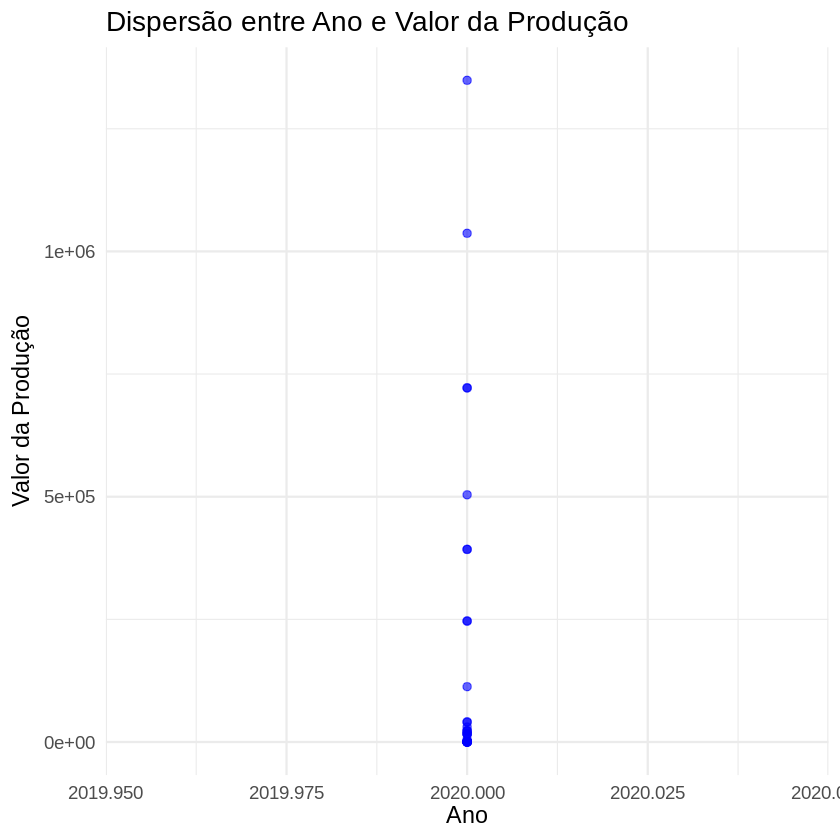

In [51]:
#29.Crie um gráfico de dispersão (scatterplot) com duas variáveis numéricas.
library(ggplot2)

# Garantir que as colunas estão no tipo correto
dados_agricola$Ano <- as.numeric(dados_agricola$Ano)
dados_agricola$Valor <- as.numeric(dados_agricola$Valor)

# Selecionar apenas os 100 primeiros registros para facilitar a visualização
dados_plot <- head(dados_agricola, 100)

# Criando o scatterplot
ggplot(dados_plot, aes(x = Ano, y = Valor)) +
  geom_point(color = "blue", size = 2, alpha = 0.6) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Dispersão entre Ano e Valor da Produção",
    x = "Ano",
    y = "Valor da Produção"
  )



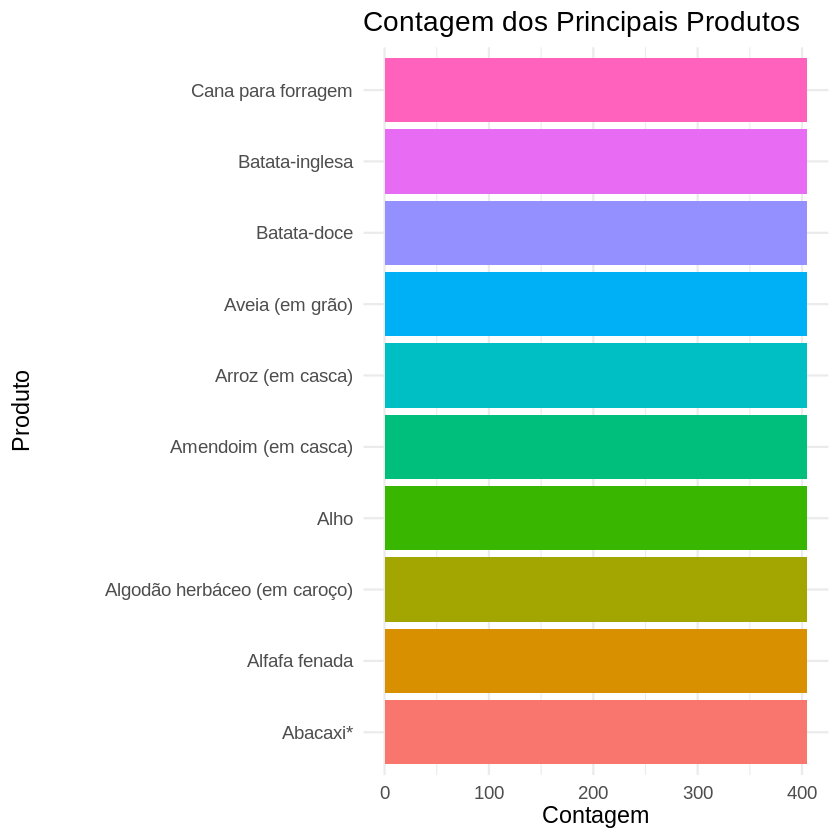

In [52]:
#30.Crie um gráfico de barras de uma variável categórica.
library(ggplot2)
library(dplyr)

# Usando apenas os 10 primeiros produtos para simplificar
df_barras <- dados_agricola %>%
  filter(!is.na(`Produto das lavouras temporárias`)) %>%
  group_by(`Produto das lavouras temporárias`) %>%
  summarise(contagem = n(), .groups = "drop") %>%
  slice_head(n = 10)  # pegar só os 10 primeiros

# Gráfico de barras
ggplot(df_barras, aes(x = reorder(`Produto das lavouras temporárias`, contagem), y = contagem, fill = `Produto das lavouras temporárias`)) +
  geom_col() +
  coord_flip() +  # barras horizontais para melhor visualização
  theme_minimal(base_size = 14) +
  labs(title = "Contagem dos Principais Produtos",
       x = "Produto",
       y = "Contagem") +
  theme(legend.position = "none")


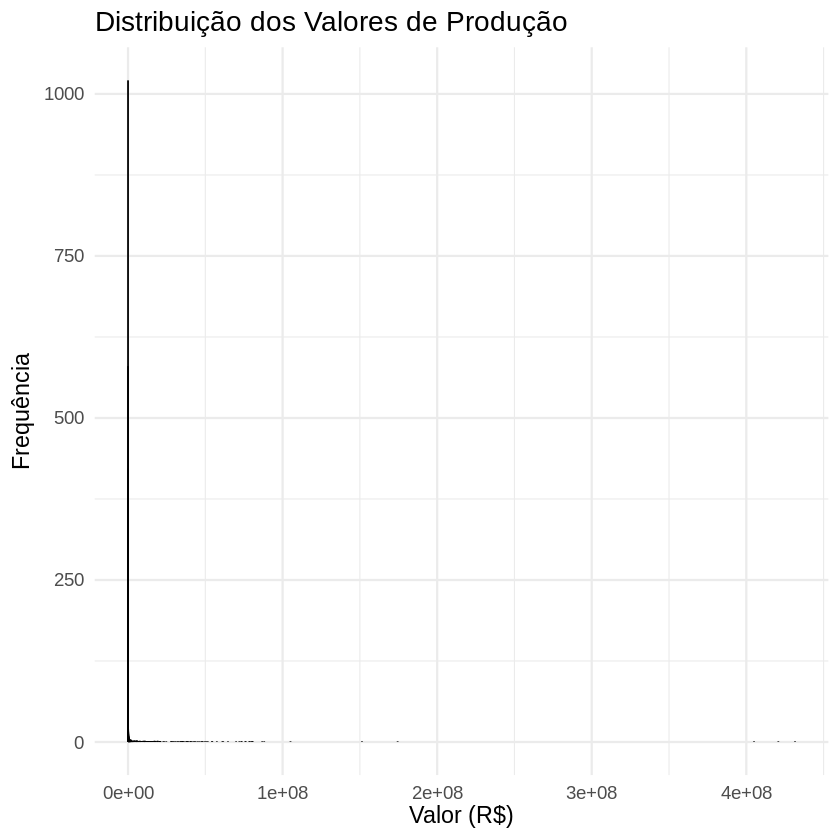

In [53]:
#31.Construa um histograma de uma variável numérica.
library(ggplot2)
library(dplyr)

# Selecionar apenas linhas com valor não nulo
df_hist <- dados_agricola %>%
  filter(!is.na(Valor))

# Histograma
ggplot(df_hist, aes(x = Valor)) +
  geom_histogram(binwidth = 1000, fill = "skyblue", color = "black") +
  theme_minimal(base_size = 14) +
  labs(title = "Distribuição dos Valores de Produção",
       x = "Valor (R$)",
       y = "Frequência")


# A tibble: 3 × 2
    Ano total_producao
  <int>          <dbl>
1  2020      365419389
2  2021      553981633
3  2022      550986979


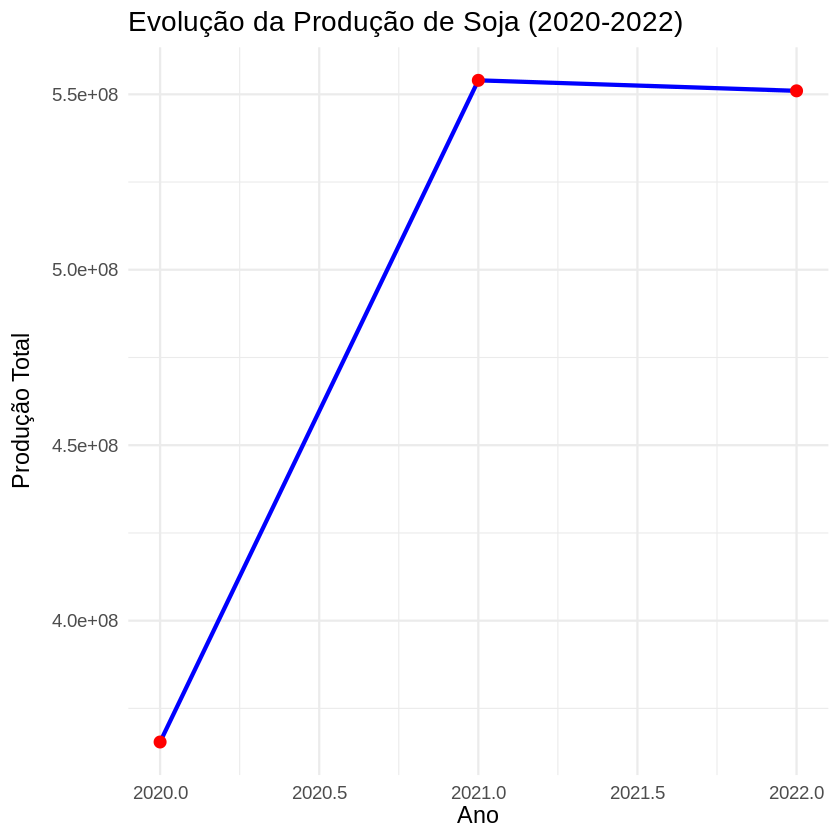

In [54]:
#32.Crie um gráfico de linha para visualizar a evolução de uma variável ao longo do tempo.
library(dplyr)
library(ggplot2)

dados_agricola <- dados_agricola %>%
  mutate(
    Valor = as.numeric(`Valor`),
    Ano = as.integer(`Ano`),
    Produto = as.factor(`Produto das lavouras temporárias`)
  )

df_linha <- dados_agricola %>%
  filter(!is.na(Valor), Produto == "Soja (em grão)") %>%
  group_by(Ano) %>%
  summarise(total_producao = sum(Valor, na.rm = TRUE), .groups = "drop")

print(df_linha)

ggplot(df_linha, aes(x = Ano, y = total_producao)) +
  geom_line(color = "blue", size = 1.2) +
  geom_point(color = "red", size = 3) +
  theme_minimal(base_size = 14) +
  labs(title = "Evolução da Produção de Soja (2020-2022)",
       x = "Ano",
       y = "Produção Total")



`geom_smooth()` using formula = 'y ~ x'


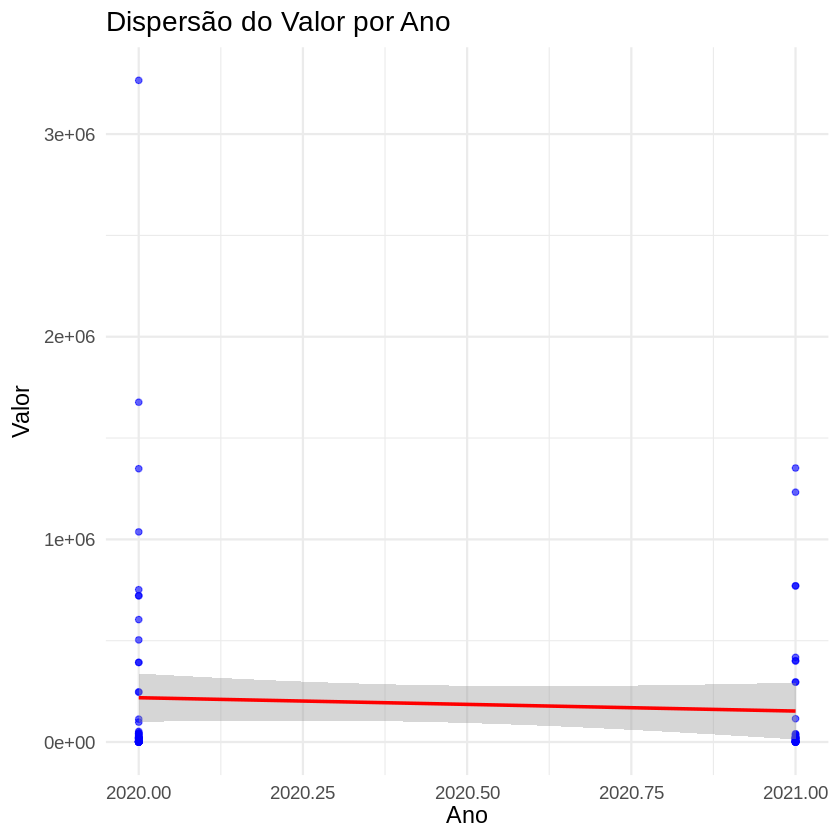

In [55]:
#33. Adicione uma linha de tendência a um gráfico de dispersão.

dados_corrigidos <- dados_agricola %>%
  select(
    Estado = `Unidade da Federação`,
    Produto = `Produto das lavouras temporárias`,
    Valor = `Valor`,
    Ano = `Ano`
  ) %>%
  filter(!is.na(Valor)) %>%
  slice_head(n = 100)

# Gráfico de dispersão com linha de tendência
ggplot(dados_corrigidos, aes(x = Ano, y = Valor)) +
  geom_point(color = "blue", alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Dispersão do Valor por Ano",
    x = "Ano",
    y = "Valor"
  )




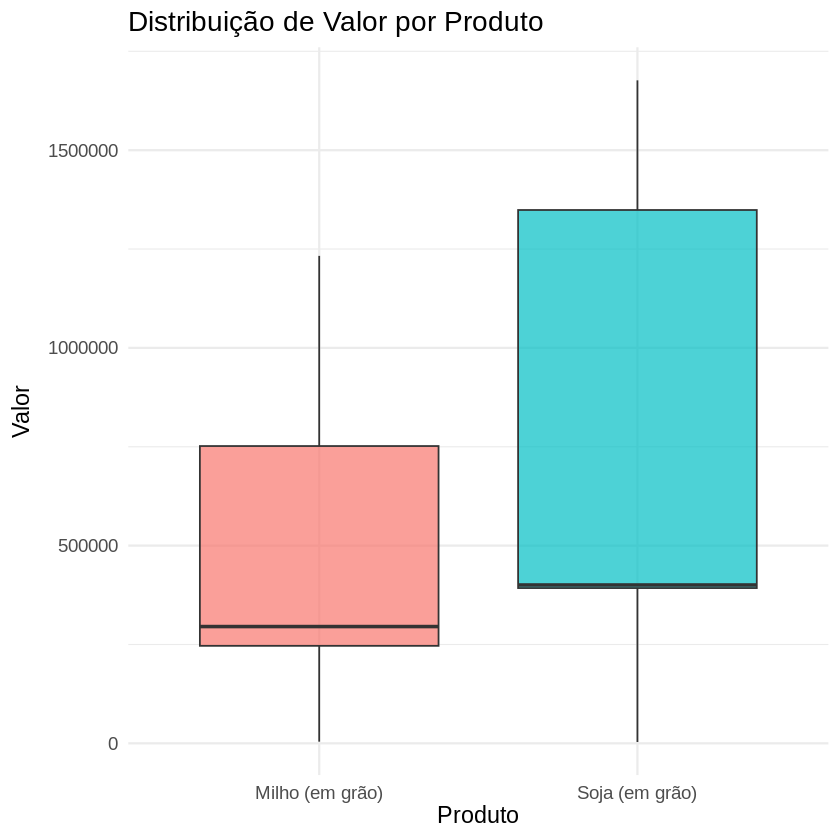

In [56]:
#34.Crie um boxplot para comparar a distribuição de uma variável numérica entre

# Filtrando produtos para simplificar
dados_boxplot <- dados_corrigidos %>%
  filter(Produto %in% c("Soja (em grão)", "Milho (em grão)"))

# Criando boxplot
ggplot(dados_boxplot, aes(x = Produto, y = Valor, fill = Produto)) +
  geom_boxplot(alpha = 0.7) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Distribuição de Valor por Produto",
    x = "Produto",
    y = "Valor"
  ) +
  theme(legend.position = "none")


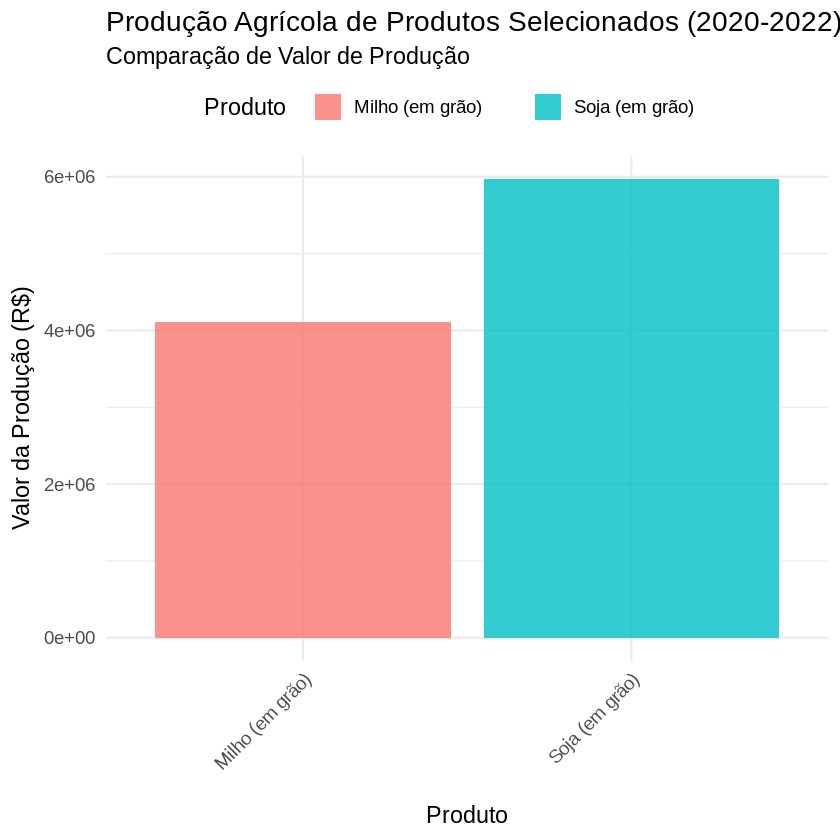

In [57]:
#35. Personalize um gráfico com título, legenda e rótulos nos eixos.

# Filtrar apenas alguns produtos para simplificação
dados_grafico <- dados_corrigidos %>%
  filter(Produto %in% c("Soja (em grão)", "Milho (em grão)"))

# Criar gráfico de barras com personalização
ggplot(dados_grafico, aes(x = Produto, y = Valor, fill = Produto)) +
  geom_col(alpha = 0.8) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Produção Agrícola de Produtos Selecionados (2020-2022)",
    subtitle = "Comparação de Valor de Produção",
    x = "Produto",
    y = "Valor da Produção (R$)",
    fill = "Produto"
  ) +
  theme(
    legend.position = "top",
    axis.text.x = element_text(angle = 45, hjust = 1)
  )


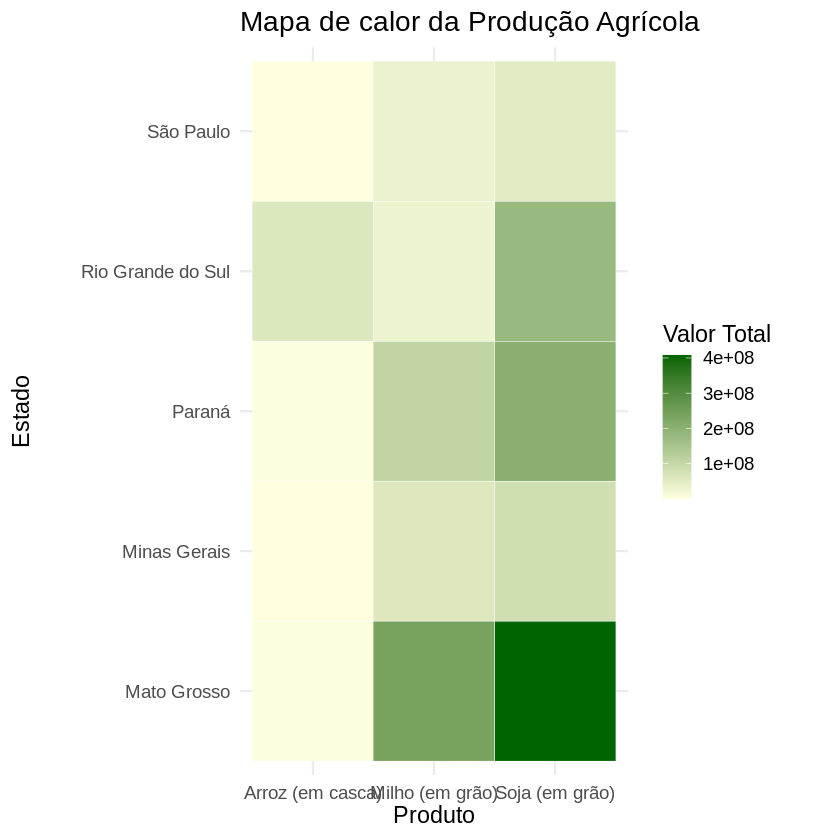

In [58]:
#36.Crie um mapa de calor (heatmap) com duas variáveis categóricas
# Carregar pacotes
library(dplyr)
library(ggplot2)

# 1. Selecionar apenas as colunas únicas relevantes
dados_heatmap <- dados_agricola %>%
  select(`Unidade da Federação`, `Produto das lavouras temporárias`, Valor) %>%
  rename(
    Estado = `Unidade da Federação`,
    Produto = `Produto das lavouras temporárias`
  ) %>%
  filter(!is.na(Valor)) %>%  # remover NA
  # Filtrar alguns produtos e estados para simplificar
  filter(Produto %in% c("Soja (em grão)", "Milho (em grão)", "Arroz (em casca)"),
         Estado %in% c("São Paulo", "Minas Gerais", "Paraná", "Rio Grande do Sul", "Mato Grosso")) %>%
  group_by(Estado, Produto) %>%
  summarise(total_valor = sum(as.numeric(Valor), na.rm = TRUE), .groups = "drop")

# 2. Criar o heatmap
ggplot(dados_heatmap, aes(x = Produto, y = Estado, fill = total_valor)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightyellow", high = "darkgreen") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Mapa de calor da Produção Agrícola",
    x = "Produto",
    y = "Estado",
    fill = "Valor Total"
  )



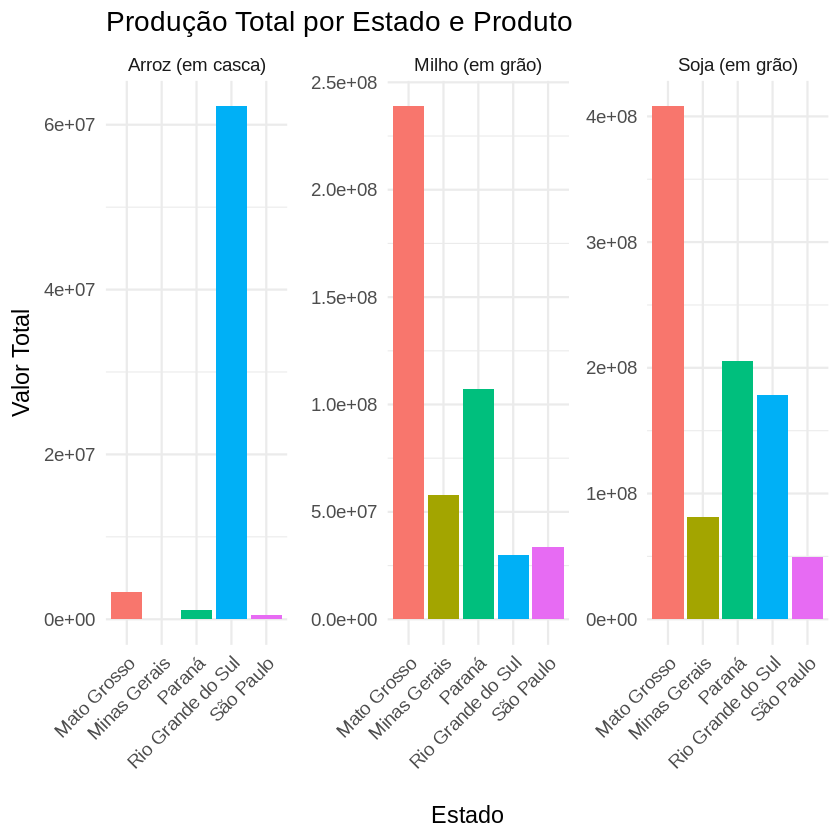

In [59]:
#37.Combine mais de um gráfico em uma mesma visualização usando facet_wrap().
library(dplyr)
library(ggplot2)

# Selecionar colunas únicas e limpar duplicatas
dados_facet <- dados_agricola %>%
  select(`Unidade da Federação`, `Produto das lavouras temporárias`, Valor) %>%
  rename(
    Estado = `Unidade da Federação`,
    Produto = `Produto das lavouras temporárias`
  ) %>%
  filter(!is.na(Valor)) %>%
  # Escolher apenas alguns produtos e estados para visualização
  filter(Produto %in% c("Soja (em grão)", "Milho (em grão)", "Arroz (em casca)"),
         Estado %in% c("São Paulo", "Minas Gerais", "Paraná", "Rio Grande do Sul", "Mato Grosso")) %>%
  group_by(Estado, Produto) %>%
  summarise(total_valor = sum(as.numeric(Valor), na.rm = TRUE), .groups = "drop")

# Gráfico de barras com facet_wrap por Produto
ggplot(dados_facet, aes(x = Estado, y = total_valor, fill = Estado)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~Produto, scales = "free_y") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Produção Total por Estado e Produto",
    x = "Estado",
    y = "Valor Total"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


**38.Crie uma função chamada resumo_variavel() que receba:**
• um dataframe,
• o nome de uma coluna numérica,
• e um parâmetro opcional plot = TRUE.
PÓS-GRADUAÇÃO EM ENGENHARIA DE DADOS
3
A função deve:
✓ Retornar um resumo estatístico da coluna (mínimo, máximo, média,
mediana e desvio padrão).
✓ Se plot = TRUE, exibir também um histograma da coluna usando ggplot2.


  Minimo Maximo    Media Mediana Desvio_Padrao
1   10.4   33.9 20.09062    19.2      6.026948


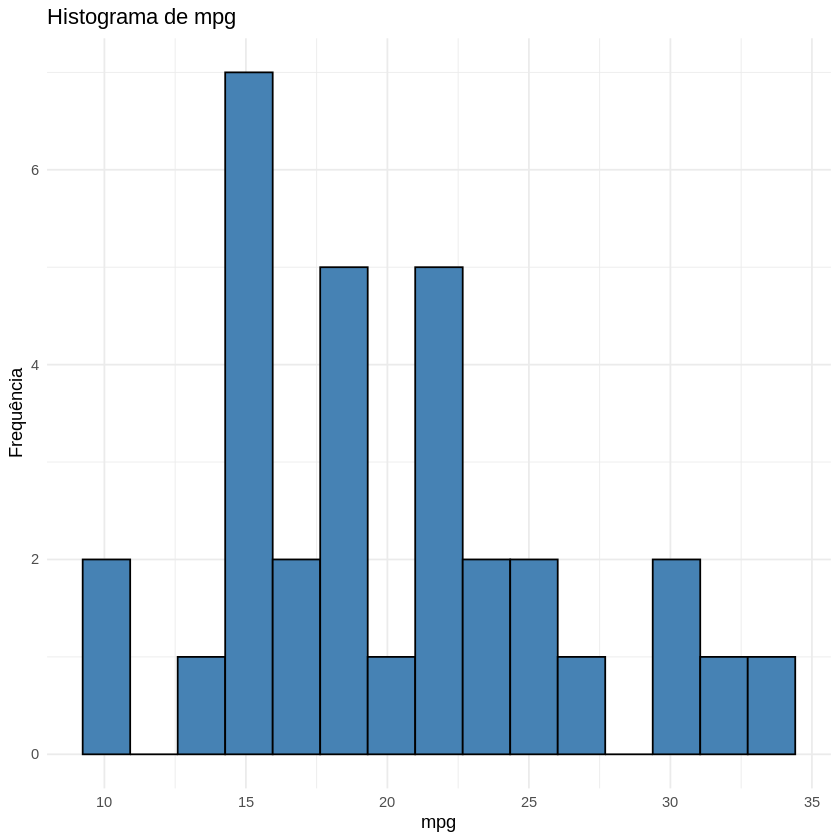

In [60]:
library(ggplot2)

resumo_variavel <- function(df, nome_coluna, plot = TRUE) {

  # Extrai a coluna
  x <- df[[nome_coluna]]

  # Calcula resumo estatístico
  resumo <- data.frame(
    Minimo = min(x, na.rm = TRUE),
    Maximo = max(x, na.rm = TRUE),
    Media = mean(x, na.rm = TRUE),
    Mediana = median(x, na.rm = TRUE),
    Desvio_Padrao = sd(x, na.rm = TRUE)
  )

  # Mostra o resumo no console
  print(resumo)

  # Mostra o gráfico se plot = TRUE
  if(plot){
    histograma <- ggplot(df, aes(x = !!sym(nome_coluna))) +
      geom_histogram(fill = "steelblue", color = "black", bins = 15) +
      labs(
        title = paste("Histograma de", nome_coluna),
        x = nome_coluna,
        y = "Frequência"
      ) +
      theme_minimal()

    print(histograma)  # garante exibição no Colab
  }
}

# Exemplo de uso:
resumo_variavel(mtcars, "mpg")


**39. Usando o operador pipe (%>%), faça as seguintes operações no seu dataset:**
• Selecione três colunas: duas numéricas e uma categórica.
• Filtre apenas as linhas em que não existam valores ausentes (NA)
nessas colunas.
• Crie uma nova coluna que seja a razão entre as duas variáveis
numéricas.
• Agrupe os dados pela variável categórica.
• Calcule a média, a mediana e o desvio padrão da nova coluna criada,
para cada grupo.
• Reorganize os resultados em formato largo (wide), de forma que cada
estatística (média, mediana, desvio) vire uma coluna separada.
• Ordene o resultado pela média em ordem decrescente.

In [61]:
library(dplyr)
library(tidyr)

# Filtrar dados de Quantidade produzida e Área colhida e selecionar colunas relevantes
dados_producao <- dados_agricola %>%
  filter(Variável == "Quantidade produzida", `Unidade de Medida` == "Toneladas") %>%
  select(Ano, `Unidade da Federação`, `Produto das lavouras temporárias`, Valor) %>%
  rename(
    Estado = `Unidade da Federação`,
    Produto = `Produto das lavouras temporárias`,
    Quantidade_Produzida = Valor
    )

dados_area_colhida <- dados_agricola %>%
  filter(Variável == "Área colhida", `Unidade de Medida` == "Hectares") %>%
  select(Ano, `Unidade da Federação`, `Produto das lavouras temporárias`, Valor) %>%
  rename(
    Estado = `Unidade da Federação`,
    Produto = `Produto das lavouras temporárias`,
    Area_Colhida = Valor
    )

# Juntar os dataframes filtrados
dados_combinados <- left_join(dados_producao, dados_area_colhida, by = c("Ano", "Estado", "Produto"))

# Calcular a razão (produtividade) e remover linhas com NA na razão
resultado <- dados_combinados %>%
  mutate(Razao = Quantidade_Produzida / Area_Colhida) %>%
  drop_na(Razao) %>% # Remover NAs que resultam da divisão ou falta de dados
  group_by(Estado) %>%
  summarise(
    media_razao   = mean(Razao, na.rm = TRUE),
    mediana_razao = median(Razao, na.rm = TRUE),
    desvio_razao  = sd(Razao, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(media_razao))

print(resultado)

# A tibble: 27 × 4
   Estado           media_razao mediana_razao desvio_razao
   <chr>                  <dbl>         <dbl>        <dbl>
 1 Goiás                   24.0          5.78         29.4
 2 Distrito Federal        23.3         16            26.4
 3 Espírito Santo          20.6         18.8          19.0
 4 Rio de Janeiro          20.4         14.7          20.0
 5 Minas Gerais            17.2          3.79         23.0
 6 Bahia                   16.1          6.66         20.5
 7 São Paulo               15.7          5.22         21.6
 8 Sergipe                 15.5         12.4          16.3
 9 Santa Catarina          15.4          8.13         16.7
10 Ceará                   14.9          3.49         20.5
# ℹ 17 more rows


**40.Construa um pipeline seguindo as instruções abaixo:**
• Selecione todas as colunas numéricas do dataset.
• Substitua valores ausentes por 0.
• Crie uma nova coluna categórica com base em uma condição aplicada a
uma variável numérica (ex.: “Alto” se > média, “Baixo” se ≤ média).
• Agrupe pelos valores da nova coluna categórica.
• Calcule média, mediana e máximo de todas as variáveis numéricas
agrupadas.
•Ordene os grupos pela média de uma coluna escolhida.

In [62]:
# Pipeline completo

resumo_pipeline <- dados_agricola %>%
  # Selecionar todas as colunas numéricas
  select(where(is.numeric)) %>%
  # Substituir NAs por 0
  mutate(across(everything(), ~replace_na(., 0))) %>%
  # Criar coluna categórica com base em Valor
  mutate(categoria_valor = ifelse(Valor > mean(Valor, na.rm = TRUE), "Alto", "Baixo")) %>%
  # Agrupar pela nova coluna categórica
  group_by(categoria_valor) %>%
  # Calcular média, mediana e máximo de todas as colunas numéricas
  summarise(across(where(is.numeric),
                   list(media = mean, mediana = median, maximo = max),
                   .names = "{col}_{fn}")) %>%
  # Ordenar pelo valor médio da coluna 'Valor'
  arrange(desc(Valor_media))

# Mostrar resultado
resumo_pipeline


categoria_valor,Valor_media,Valor_mediana,Valor_maximo,Ano_media,Ano_mediana,Ano_maximo,Valor_mil_media,Valor_mil_mediana,Valor_mil_maximo
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Alto,8799786.5,1951850,431525560,2021.023,2021,2022,8799.7865,1951.851,431525.560
Baixo,21202.2,0,547267,2020.999,2021,2022,21.2022,0.000,547.267


**41.Com o pipeline da questão 38, faça:**
a. Salve este pipeline como uma função em um arquivo R separado (ex.:
meu_pipeline.R).
b. Carregue a função do arquivo
c. Passe o dataset como argumento para a função e gere um dataset final
processado

In [63]:
library(dplyr)
library(tidyr)

resumo_produtividade <- function(df) {

  # Filtrar dados de Quantidade produzida e Área colhida e selecionar colunas relevantes

  dados_producao <- df %>%
    filter(Variável == "Quantidade produzida", `Unidade de Medida` == "Toneladas") %>%
    select(Ano, `Unidade da Federação`, `Produto das lavouras temporárias`, Valor) %>%
    rename(
      Estado = `Unidade da Federação`,
      Produto = `Produto das lavouras temporárias`,
      Quantidade_Produzida = Valor
    )

  dados_area_colhida <- df %>%
    filter(Variável == "Área colhida", `Unidade de Medida` == "Hectares") %>%
    select(Ano, `Unidade da Federação`, `Produto das lavouras temporárias`, Valor) %>%
    rename(
      Estado = `Unidade da Federação`,
      Produto = `Produto das lavouras temporárias`,
      Area_Colhida = Valor
    )

  # Juntar os dataframes filtrados

  dados_combinados <- left_join(dados_producao, dados_area_colhida,
                                by = c("Ano", "Estado", "Produto"))

  # Calcular a produtividade e remover linhas com NA
  resultado <- dados_combinados %>%
    mutate(Razao = Quantidade_Produzida / Area_Colhida) %>%
    drop_na(Razao) %>%
    group_by(Estado) %>%
    summarise(
      media_razao   = mean(Razao, na.rm = TRUE),
      mediana_razao = median(Razao, na.rm = TRUE),
      desvio_razao  = sd(Razao, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    arrange(desc(media_razao))

  return(resultado)
}


In [68]:
# carregar a função

source("meu_pipeline.R")

In [69]:
# Gerar o dataset processado
resultado_final <- resumo_produtividade(dados_agricola)

# Resultado
print(resultado_final)

# A tibble: 27 × 4
   Estado           media_razao mediana_razao desvio_razao
   <chr>                  <dbl>         <dbl>        <dbl>
 1 Goiás                   24.0          5.78         29.4
 2 Distrito Federal        23.3         16            26.4
 3 Espírito Santo          20.6         18.8          19.0
 4 Rio de Janeiro          20.4         14.7          20.0
 5 Minas Gerais            17.2          3.79         23.0
 6 Bahia                   16.1          6.66         20.5
 7 São Paulo               15.7          5.22         21.6
 8 Sergipe                 15.5         12.4          16.3
 9 Santa Catarina          15.4          8.13         16.7
10 Ceará                   14.9          3.49         20.5
# ℹ 17 more rows


In [65]:
# Save the function to a file
writeLines(capture.output(resumo_produtividade), "meu_pipeline.R")

In [66]:
# Save the function to a file named 'meu_pipeline.R'
cat(deparse(resumo_produtividade), file = "meu_pipeline.R", sep = "\n")

In [67]:
# Save the function to a file
writeLines(deparse(resumo_produtividade), "meu_pipeline.R")

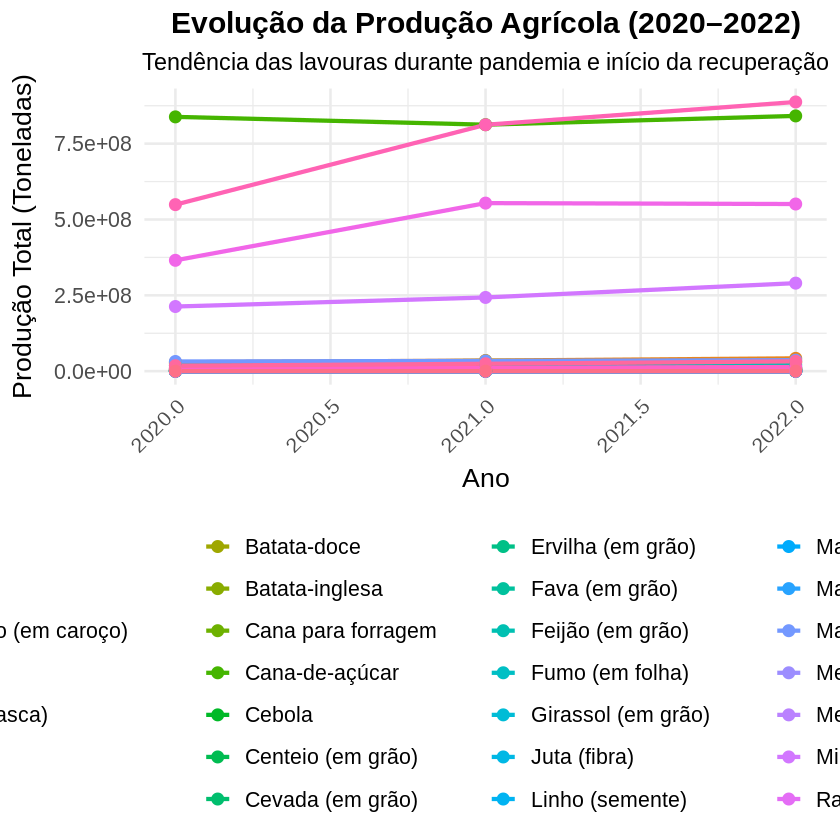

In [84]:
library(ggplot2)
library(dplyr)

dados_resumo <- dados_agricola %>%
  filter(Ano %in% c(2020, 2021, 2022)) %>%
  group_by(Ano, Produto) %>%
  summarise(Producao = sum(Valor, na.rm = TRUE), .groups = "drop")


grafico_linhas <- ggplot(dados_resumo, aes(x = Ano, y = Producao, color = Produto, group = Produto)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  labs(
    title = "Evolução da Produção Agrícola (2020–2022)",
    subtitle = "Tendência das lavouras durante pandemia e início da recuperação",
    x = "Ano",
    y = "Produção Total (Toneladas)",
    color = "Produto"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
    plot.subtitle = element_text(hjust = 0.5, size = 14),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

print(grafico_linhas)



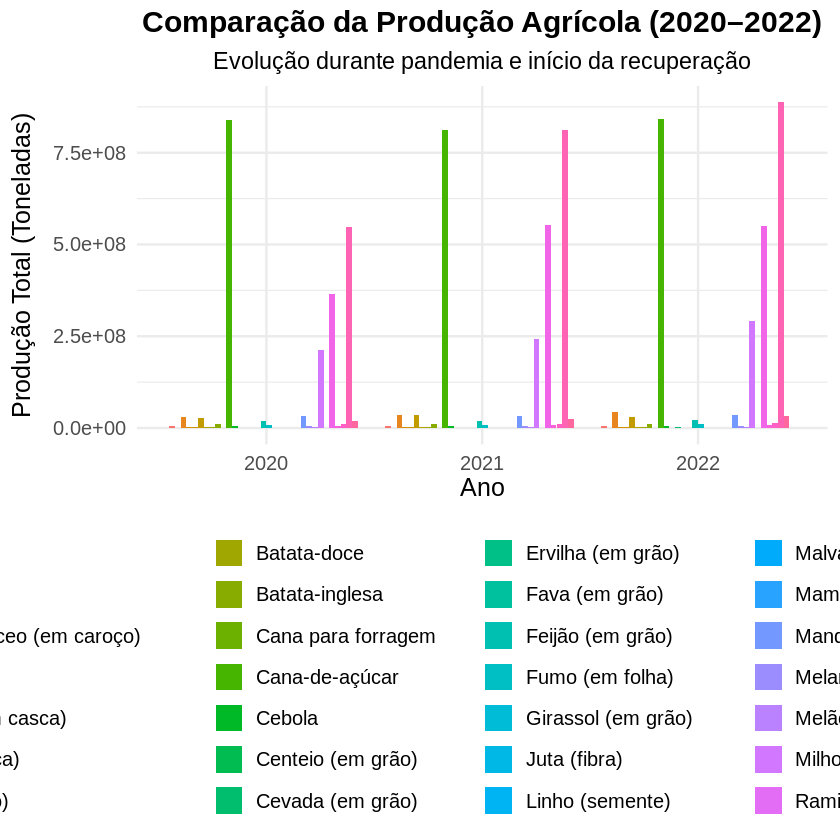

In [87]:
library(ggplot2)
library(dplyr)

dados_resumo <- dados_agricola %>%
  filter(Ano %in% c(2020, 2021, 2022)) %>%
  group_by(Ano, Produto) %>%
  summarise(Producao = sum(Valor, na.rm = TRUE), .groups = "drop")

grafico_barras <- ggplot(dados_resumo, aes(x = factor(Ano), y = Producao, fill = Produto)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Comparação da Produção Agrícola (2020–2022)",
    subtitle = "Evolução durante pandemia e início da recuperação",
    x = "Ano",
    y = "Produção Total (Toneladas)",
    fill = "Produto"
  ) +
  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
    plot.subtitle = element_text(hjust = 0.5, size = 14),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    legend.position = "bottom"
  )

print(grafico_barras)


**Análise da Produção Agrícola Brasileira (2020–2022)**
Podemos concluir que o agronegócio brasileiro representa 25% do PIB. Entre 2020 e 2022, analisamos lavouras como soja, milho e arroz para verificar o impacto da pandemia e da recuperação econômica. A produção de soja e milho cresceu, enquanto outras culturas se mantiveram estáveis. A análise por estado mostrou variações regionais, permitindo identificar áreas com maior desempenho. Esses insights ajudam a orientar investimentos em tecnologia agrícola e políticas públicas.